In [2]:
import pandas as pd

df = pd.read_excel("D598 Data Set.xlsx")

df2 = df.drop_duplicates()

df3 = df2.groupby("Business State").agg(['mean', 'median', 'min', 'max'])
df3.columns = ['_'.join(col) for col in df3.columns] 
df3.reset_index(inplace=True)

df4 = df2[df2['Debt to Equity'] < 0]

df5 = df2.apply(
    lambda row: 0 if row['Total Revenue'] == 0 else row['Total Long-term Debt'] / row['Total Revenue'],
    axis=1
)
df5 = pd.DataFrame(df5, columns=['Debt-to-Income Ratio'])

df6 = pd.concat([df2, df5], axis=1)

In [3]:
display (df6)

,Business ID,Business State,Total Long-term Debt,Total Equity,Debt to Equity,Total Liabilities,Total Revenue,Profit Margin,Debt-to-Income Ratio
0,41872013,Kentucky,16889000.0,1.804600e+07,0.935886,2.598600e+07,136753000,0.023663,0.123500
1,76232013,Iowa,6252000.0,1.829362e+07,0.341758,1.447400e+07,34226553,0.265015,0.182665
2,160992013,Texas,19200000.0,1.778580e+08,0.107951,7.278700e+07,384196000,0.130413,0.049974
3,197452013,Delaware,117592000.0,2.787730e+08,0.421820,5.587490e+08,444306000,0.196768,0.264664
4,241042013,Illinois,4408000.0,5.206400e+07,0.084665,1.989800e+07,121541000,0.168305,0.036268
...,...,...,...,...,...,...,...,...,...
145,14733342013,California,6602000.0,3.872871e+07,0.170468,2.183800e+07,78356493,0.213007,0.084256
146,14871012013,Maryland,56000000.0,2.813310e+08,0.199054,1.476180e+08,298732000,0.353230,0.187459
147,14889172013,MInnesota,1332000.0,1.392683e+07,0.095643,3.629000e+06,15104422,0.727563,0.088186
148,15456542013,Hawaii,605500000.0,1.173200e+09,0.516110,1.110400e+09,365200000,0.348850,1.657996


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

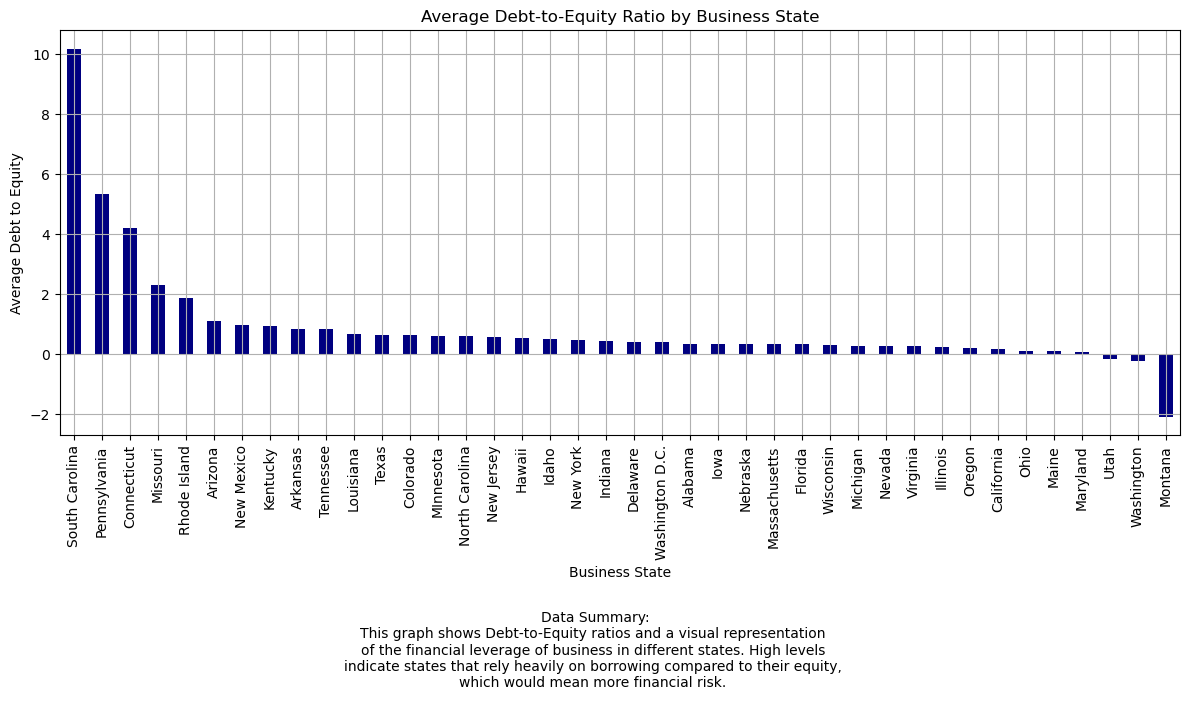

In [5]:
dept_to_equity_by_state = df6.groupby('Business State')['Debt to Equity'].mean().sort_values(ascending=False)
plt.figure(figsize=(12,6))
dept_to_equity_by_state.plot(kind='bar', color='navy')
plt.title('Average Debt-to-Equity Ratio by Business State')
plt.xlabel('Business State')
plt.ylabel('Average Debt to Equity')
plt.xticks(rotation=90)
plt.grid(True)
summary_dte = f"""
Data Summary:
This graph shows Debt-to-Equity ratios and a visual representation 
of the financial leverage of business in different states. High levels 
indicate states that rely heavily on borrowing compared to their equity, 
which would mean more financial risk. 
"""
plt.figtext(0.5, 0.0, summary_dte, fontsize=10, ha='center', va='top') 
plt.tight_layout()


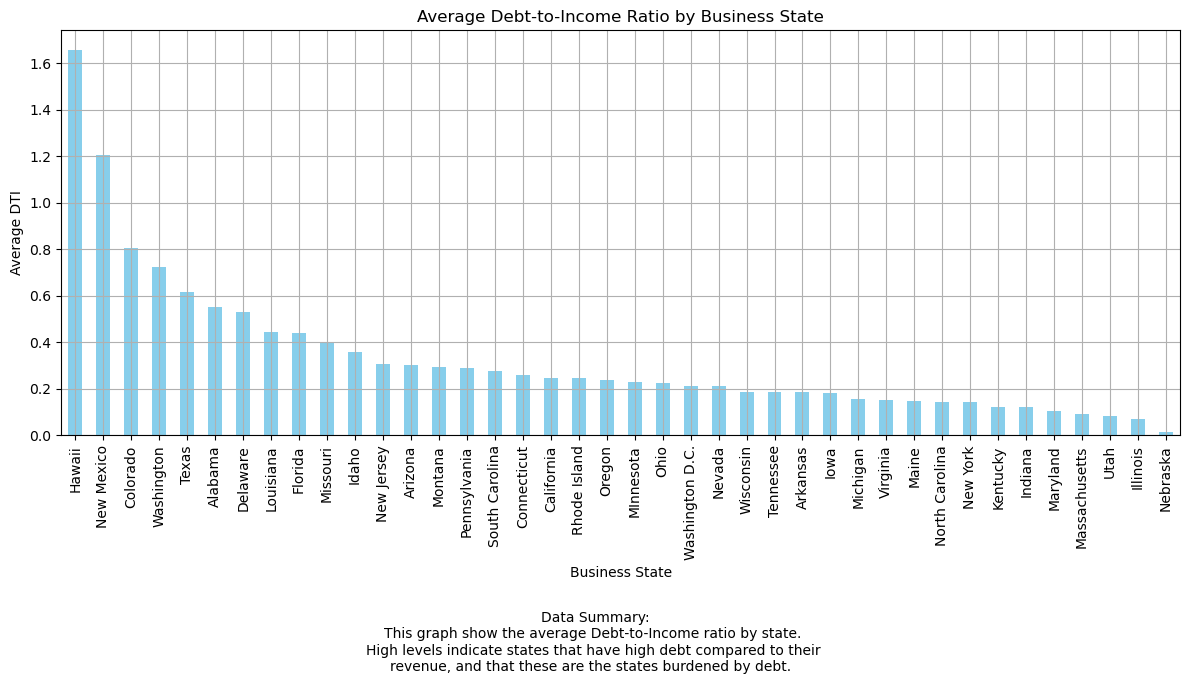

In [6]:
state_avg_dti = df6.groupby('Business State')['Debt-to-Income Ratio'].mean().sort_values(ascending=False)
plt.figure(figsize=(12,6))
state_avg_dti.plot(kind='bar', color='skyblue')
plt.title('Average Debt-to-Income Ratio by Business State')
plt.xlabel('Business State')
plt.ylabel('Average DTI')
plt.xticks(rotation=90)
plt.grid(True)
summary_dti = f"""
Data Summary:
This graph show the average Debt-to-Income ratio by state. 
High levels indicate states that have high debt compared to their 
revenue, and that these are the states burdened by debt.  
"""
plt.figtext(0.5, -0.0, summary_dti, fontsize=10, ha='center', va='top') 
plt.tight_layout()
plt.show()


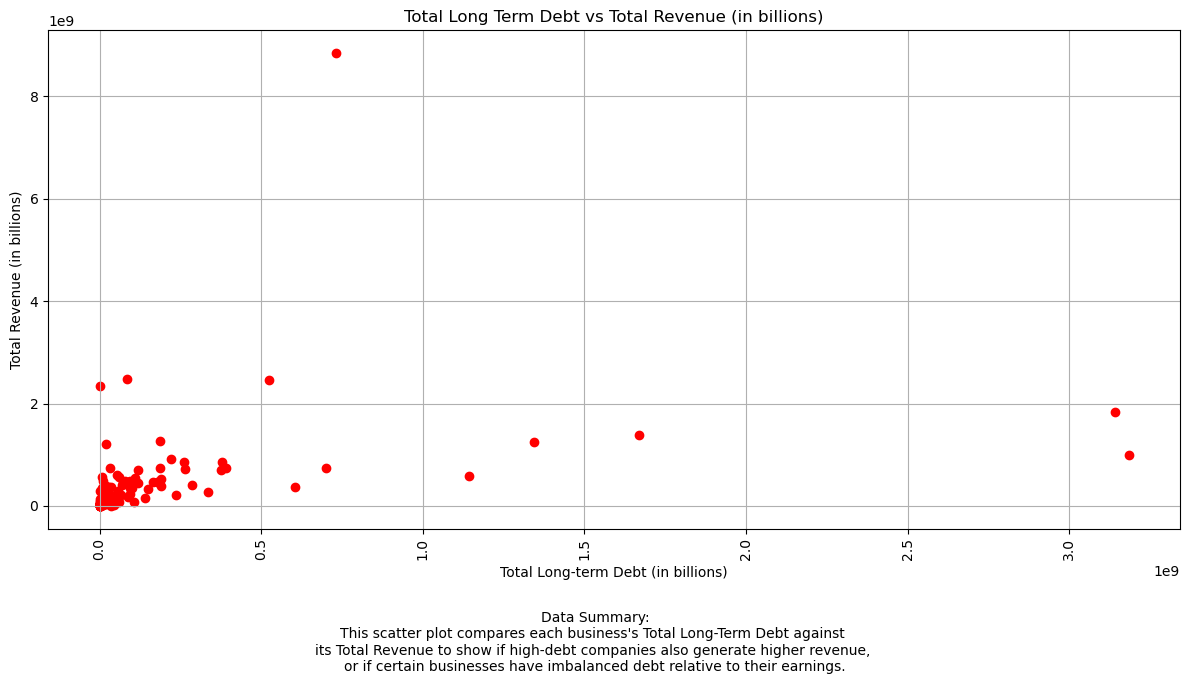

In [7]:
plt.figure(figsize=(12,6))
plt.scatter(df['Total Long-term Debt'], df['Total Revenue'], color='red')
plt.title('Total Long Term Debt vs Total Revenue (in billions)')
plt.xlabel('Total Long-term Debt (in billions)')
plt.ylabel('Total Revenue (in billions)')
plt.xticks(rotation=90)
plt.grid(True)
summary_scatter = f"""
Data Summary:
This scatter plot compares each business's Total Long-Term Debt against 
its Total Revenue to show if high-debt companies also generate higher revenue, 
or if certain businesses have imbalanced debt relative to their earnings.
"""
plt.figtext(0.5, -0.0, summary_scatter, fontsize=10, ha='center', va='top') 
plt.tight_layout()
plt.show()


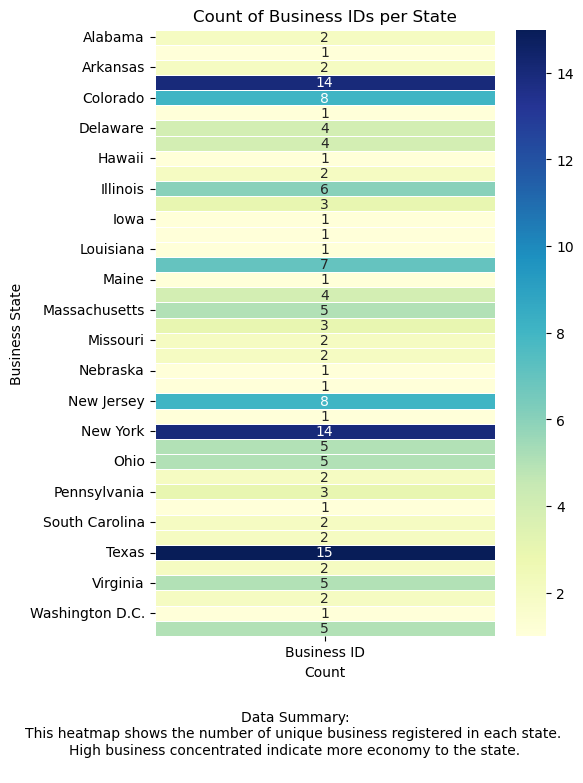

In [8]:
state_counts = df6.groupby('Business State')['Business ID'].count().reset_index()

heatmap_data = state_counts.pivot_table(index='Business State', values='Business ID')

plt.figure(figsize=(6,7)) 
sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlGnBu', linewidths=0.5)
plt.title('Count of Business IDs per State')
plt.xlabel('Count')
plt.ylabel('Business State')
summary_scatter = f"""
Data Summary:
This heatmap shows the number of unique business registered in each state. 
High business concentrated indicate more economy to the state.
"""
plt.figtext(0.5, -0.0, summary_scatter, fontsize=10, ha='center', va='top') 
plt.tight_layout()
plt.show()

In [9]:
print (df3)

     Business State  Business ID_mean  Business ID_median  Business ID_min  \
0           Alabama      1.599117e+09        1.599117e+09        422282013   
1           Arizona      9.445082e+09        9.445082e+09       9445082013   
2          Arkansas      8.411162e+09        8.411162e+09       7982872013   
3        California      1.063053e+10        1.034300e+10       7192742013   
4          Colorado      9.966963e+09        1.008177e+10       3194582013   
5       Connecticut      1.123316e+10        1.123316e+10      11233162013   
6          Delaware      6.936917e+09        8.686742e+09        197452013   
7           Florida      7.520922e+09        8.670152e+09       3507372013   
8            Hawaii      1.545654e+10        1.545654e+10      15456542013   
9             Idaho      1.181126e+10        1.181126e+10      10382772013   
10         Illinois      5.950345e+09        7.590952e+09        241042013   
11          Indiana      2.767492e+09        7.660520e+08       